<a href="https://www.kaggle.com/code/shoshanamiriamlevin/credit-card-model-by-yaakov-levin?scriptVersionId=317352910" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

### 📊 Problem Statement

The bank is experiencing financial losses each month due to fraudulent transactions. To address this issue, a data analyst has been tasked with developing a predictive model to identify and prevent fraud.

In [1]:
import polars as pl
import pandas as pd 
import numpy as np 


df = pl.read_csv('/kaggle/input/datasets/orogunadebola/credit-card-transaction-dataset-fraud-detection/data.csv')

In [2]:
df.schema
#we cheak our colunms 

Schema([('ssn', String),
        ('cc_num', Int64),
        ('first', String),
        ('last', String),
        ('gender', String),
        ('street', String),
        ('city', String),
        ('state', String),
        ('zip', Int64),
        ('lat', Float64),
        ('long', Float64),
        ('city_pop', Int64),
        ('job', String),
        ('dob', String),
        ('acct_num', Int64),
        ('profile', String),
        ('trans_num', String),
        ('trans_date', String),
        ('trans_time', String),
        ('unix_time', Int64),
        ('category', String),
        ('amt', Float64),
        ('is_fraud', Int64),
        ('merchant', String),
        ('merch_lat', Float64),
        ('merch_long', Float64),
        ('customer_num_trans_1_day', Int64),
        ('customer_num_trans_7_day', Int64),
        ('customer_num_trans_30_day', Int64),
        ('trans_time_secs', Int64),
        ('trans_time_hrs', Int64),
        ('trans_time_is_night', Int64),
        ('trans_time

In [3]:
df = df.drop("acct_num")


In [4]:
df.head()

ssn,cc_num,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,profile,trans_num,trans_date,trans_time,unix_time,category,amt,is_fraud,merchant,merch_lat,merch_long,customer_num_trans_1_day,customer_num_trans_7_day,customer_num_trans_30_day,trans_time_secs,trans_time_hrs,trans_time_is_night,trans_time_day,trans_date_is_weekend,customer_avg_amout_1_day,customer_avg_amount_7_day,customer_avg_amount_30_day,merchant_num_trans_1_day,merchant_num_trans_7_day,merchant_num_trans_30_day,merchant_risk_1_day,merchant_risk_7_day,merchant_risk_30_day,merchant_risk_90_day
str,i64,str,str,str,str,str,str,i64,f64,f64,i64,str,str,str,str,str,str,i64,str,f64,i64,str,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""024-79-2449""",30417925130692,"""Felicia""","""Gomez""","""F""","""486 Benson Stravenue""","""Rockford""","""IL""",61107,42.2786,-89.0361,189162,"""Accountant, chartered manageme…","""1995-09-17""","""adults_2550_female_urban.json""","""1a91d07261b8e16242126081f37087…","""2023-01-28""","""13:02:02""",1674907322,"""home""",615.41,0,"""fraud_Champlin and Sons""",42.13534,-89.171111,2,3,12,6762,22,1,5,1,4.01,18.27,6.97,4824.23,73065.81,141799.95,4,13,20,14
"""269-54-1394""",4224979584238239,"""Jeffrey""","""Mathews""","""M""","""5430 Leslie Flat Suite 854""","""Ceres""","""CA""",95307,37.5833,-120.9496,42753,"""Medical secretary""","""1957-10-05""","""adults_50up_male_urban.json""","""e85e0881922637f40a3601f1d96505…","""2022-07-09""","""04:29:11""",1657337351,"""grocery_pos""",61.56,0,"""fraud_Doyle Ltd""",36.664667,-120.679995,4,9,17,56775,23,1,5,1,88.83,77.27,8.06,3243.55,51496.77,1093950.5,3,10,11,28
"""527-16-1817""",4056555304074394,"""Christina""","""Ellis""","""F""","""75933 Harvey Via Apt. 423""","""Buffalo""","""NY""",14224,42.8371,-78.7484,564824,"""Surveyor, insurance""","""1989-08-12""","""adults_2550_female_urban.json""","""bba131a81aa5fa3d38970c1e4bf95b…","""2022-07-12""","""11:02:17""",1657620137,"""misc_net""",58.63,0,"""fraud_Schmitt Ltd""",42.005869,-79.21068,0,1,7,26350,16,0,1,0,66.96,67.47,43.41,4242.22,26384.49,1.0059e6,6,14,23,48
"""314-98-4472""",6011544296258081,"""Steven""","""Murphy""","""M""","""268 Anderson Valley Apt. 958""","""Mansfield Center""","""CT""",6250,41.7698,-72.2011,4821,"""Administrator, sports""","""1960-04-04""","""adults_50up_male_urban.json""","""7bd0d965cd408600df215604b555b9…","""2022-06-19""","""05:17:43""",1655612263,"""grocery_pos""",67.88,0,"""fraud_Doyle Ltd""",41.619398,-72.73701,0,5,13,49334,20,0,6,1,15.32,58.22,52.05,4303.16,3476.36,226662.34,3,11,14,14
"""390-83-9961""",374917808855764,"""Cynthia""","""Martinez""","""F""","""53164 Deborah Square Apt. 739""","""Anaheim""","""CA""",92804,33.8186,-117.9729,354475,"""Engineer, water""","""1977-02-23""","""adults_2550_female_urban.json""","""f160dd77d3916b44d5c7a8840670e0…","""2022-05-31""","""02:03:53""",1653959033,"""grocery_net""",39.73,0,"""fraud_Hills-Olson""",33.937114,-117.32468,0,0,6,18342,8,0,1,0,28.81,44.64,24.65,2424.13,32215.14,36989.6,2,13,16,20


In [5]:
import polars as pl

# Calculate the total amount lost to fraud
total_fraud = df.filter(pl.col("is_fraud") == 1).select(pl.col("amt").sum())


total_economic_loss = total_fraud 

print(total_economic_loss)

shape: (1, 1)
┌──────────┐
│ amt      │
│ ---      │
│ f64      │
╞══════════╡
│ 5.1266e7 │
└──────────┘


### 💳 Fraud Loss Insight

Based on the analysis, the total estimated loss due to fraud is **51,266,000**, highlighting a significant financial impact on the bank.

In [6]:
avg_fraud_cost = df.filter(pl.col("is_fraud") == 1) \
                   .select(pl.col("amt").mean())
avg_fraud_cost

amt
f64
540.745401


### 💳 Average Fraud Transaction

The average cost of a fraudulent transaction is approximately **540**.

In [7]:
df.shape

(8580255, 43)

In [8]:
#we first have to change our columns so we can make our model 

# 1. Drop columns that don't help the model learn general patterns
cols_to_drop = ["first", "last", "street", "trans_num", "unix_time","merchant"]
df = df.drop(cols_to_drop)

# 2. Convert Gender to 0 and 1 (Binary Encoding)
df = df.with_columns(
    pl.col("gender").replace({"M": 1, "F": 0}).cast(pl.Int8)
)





In [9]:
df.head()

ssn,cc_num,gender,city,state,zip,lat,long,city_pop,job,dob,profile,trans_date,trans_time,category,amt,is_fraud,merch_lat,merch_long,customer_num_trans_1_day,customer_num_trans_7_day,customer_num_trans_30_day,trans_time_secs,trans_time_hrs,trans_time_is_night,trans_time_day,trans_date_is_weekend,customer_avg_amout_1_day,customer_avg_amount_7_day,customer_avg_amount_30_day,merchant_num_trans_1_day,merchant_num_trans_7_day,merchant_num_trans_30_day,merchant_risk_1_day,merchant_risk_7_day,merchant_risk_30_day,merchant_risk_90_day
str,i64,i8,str,str,i64,f64,f64,i64,str,str,str,str,str,str,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""024-79-2449""",30417925130692,0,"""Rockford""","""IL""",61107,42.2786,-89.0361,189162,"""Accountant, chartered manageme…","""1995-09-17""","""adults_2550_female_urban.json""","""2023-01-28""","""13:02:02""","""home""",615.41,0,42.13534,-89.171111,2,3,12,6762,22,1,5,1,4.01,18.27,6.97,4824.23,73065.81,141799.95,4,13,20,14
"""269-54-1394""",4224979584238239,1,"""Ceres""","""CA""",95307,37.5833,-120.9496,42753,"""Medical secretary""","""1957-10-05""","""adults_50up_male_urban.json""","""2022-07-09""","""04:29:11""","""grocery_pos""",61.56,0,36.664667,-120.679995,4,9,17,56775,23,1,5,1,88.83,77.27,8.06,3243.55,51496.77,1093950.5,3,10,11,28
"""527-16-1817""",4056555304074394,0,"""Buffalo""","""NY""",14224,42.8371,-78.7484,564824,"""Surveyor, insurance""","""1989-08-12""","""adults_2550_female_urban.json""","""2022-07-12""","""11:02:17""","""misc_net""",58.63,0,42.005869,-79.21068,0,1,7,26350,16,0,1,0,66.96,67.47,43.41,4242.22,26384.49,1.0059e6,6,14,23,48
"""314-98-4472""",6011544296258081,1,"""Mansfield Center""","""CT""",6250,41.7698,-72.2011,4821,"""Administrator, sports""","""1960-04-04""","""adults_50up_male_urban.json""","""2022-06-19""","""05:17:43""","""grocery_pos""",67.88,0,41.619398,-72.73701,0,5,13,49334,20,0,6,1,15.32,58.22,52.05,4303.16,3476.36,226662.34,3,11,14,14
"""390-83-9961""",374917808855764,0,"""Anaheim""","""CA""",92804,33.8186,-117.9729,354475,"""Engineer, water""","""1977-02-23""","""adults_2550_female_urban.json""","""2022-05-31""","""02:03:53""","""grocery_net""",39.73,0,33.937114,-117.32468,0,0,6,18342,8,0,1,0,28.81,44.64,24.65,2424.13,32215.14,36989.6,2,13,16,20


In [10]:
df.shape

(8580255, 37)

In [11]:
df.head()

ssn,cc_num,gender,city,state,zip,lat,long,city_pop,job,dob,profile,trans_date,trans_time,category,amt,is_fraud,merch_lat,merch_long,customer_num_trans_1_day,customer_num_trans_7_day,customer_num_trans_30_day,trans_time_secs,trans_time_hrs,trans_time_is_night,trans_time_day,trans_date_is_weekend,customer_avg_amout_1_day,customer_avg_amount_7_day,customer_avg_amount_30_day,merchant_num_trans_1_day,merchant_num_trans_7_day,merchant_num_trans_30_day,merchant_risk_1_day,merchant_risk_7_day,merchant_risk_30_day,merchant_risk_90_day
str,i64,i8,str,str,i64,f64,f64,i64,str,str,str,str,str,str,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""024-79-2449""",30417925130692,0,"""Rockford""","""IL""",61107,42.2786,-89.0361,189162,"""Accountant, chartered manageme…","""1995-09-17""","""adults_2550_female_urban.json""","""2023-01-28""","""13:02:02""","""home""",615.41,0,42.13534,-89.171111,2,3,12,6762,22,1,5,1,4.01,18.27,6.97,4824.23,73065.81,141799.95,4,13,20,14
"""269-54-1394""",4224979584238239,1,"""Ceres""","""CA""",95307,37.5833,-120.9496,42753,"""Medical secretary""","""1957-10-05""","""adults_50up_male_urban.json""","""2022-07-09""","""04:29:11""","""grocery_pos""",61.56,0,36.664667,-120.679995,4,9,17,56775,23,1,5,1,88.83,77.27,8.06,3243.55,51496.77,1093950.5,3,10,11,28
"""527-16-1817""",4056555304074394,0,"""Buffalo""","""NY""",14224,42.8371,-78.7484,564824,"""Surveyor, insurance""","""1989-08-12""","""adults_2550_female_urban.json""","""2022-07-12""","""11:02:17""","""misc_net""",58.63,0,42.005869,-79.21068,0,1,7,26350,16,0,1,0,66.96,67.47,43.41,4242.22,26384.49,1.0059e6,6,14,23,48
"""314-98-4472""",6011544296258081,1,"""Mansfield Center""","""CT""",6250,41.7698,-72.2011,4821,"""Administrator, sports""","""1960-04-04""","""adults_50up_male_urban.json""","""2022-06-19""","""05:17:43""","""grocery_pos""",67.88,0,41.619398,-72.73701,0,5,13,49334,20,0,6,1,15.32,58.22,52.05,4303.16,3476.36,226662.34,3,11,14,14
"""390-83-9961""",374917808855764,0,"""Anaheim""","""CA""",92804,33.8186,-117.9729,354475,"""Engineer, water""","""1977-02-23""","""adults_2550_female_urban.json""","""2022-05-31""","""02:03:53""","""grocery_net""",39.73,0,33.937114,-117.32468,0,0,6,18342,8,0,1,0,28.81,44.64,24.65,2424.13,32215.14,36989.6,2,13,16,20


In [12]:
df.null_count()

ssn,cc_num,gender,city,state,zip,lat,long,city_pop,job,dob,profile,trans_date,trans_time,category,amt,is_fraud,merch_lat,merch_long,customer_num_trans_1_day,customer_num_trans_7_day,customer_num_trans_30_day,trans_time_secs,trans_time_hrs,trans_time_is_night,trans_time_day,trans_date_is_weekend,customer_avg_amout_1_day,customer_avg_amount_7_day,customer_avg_amount_30_day,merchant_num_trans_1_day,merchant_num_trans_7_day,merchant_num_trans_30_day,merchant_risk_1_day,merchant_risk_7_day,merchant_risk_30_day,merchant_risk_90_day
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [13]:
df.schema

Schema([('ssn', String),
        ('cc_num', Int64),
        ('gender', Int8),
        ('city', String),
        ('state', String),
        ('zip', Int64),
        ('lat', Float64),
        ('long', Float64),
        ('city_pop', Int64),
        ('job', String),
        ('dob', String),
        ('profile', String),
        ('trans_date', String),
        ('trans_time', String),
        ('category', String),
        ('amt', Float64),
        ('is_fraud', Int64),
        ('merch_lat', Float64),
        ('merch_long', Float64),
        ('customer_num_trans_1_day', Int64),
        ('customer_num_trans_7_day', Int64),
        ('customer_num_trans_30_day', Int64),
        ('trans_time_secs', Int64),
        ('trans_time_hrs', Int64),
        ('trans_time_is_night', Int64),
        ('trans_time_day', Int64),
        ('trans_date_is_weekend', Int64),
        ('customer_avg_amout_1_day', Float64),
        ('customer_avg_amount_7_day', Float64),
        ('customer_avg_amount_30_day', Float64),
  

In [14]:
from datetime import date

# Get today's date
today = date.today()

df = df.with_columns(
    # 1. Ensure dob is a Date type
    pl.col("dob").str.to_date("%Y-%m-%d")
).with_columns(
    # 2. Removed the extra [ ] brackets here
    ((today - pl.col("dob")).dt.total_days() / 365.25).cast(pl.Int64).alias("age")
)

# Check the new column
print(df.select(["dob", "age"]).head())

shape: (5, 2)
┌────────────┬─────┐
│ dob        ┆ age │
│ ---        ┆ --- │
│ date       ┆ i64 │
╞════════════╪═════╡
│ 1995-09-17 ┆ 30  │
│ 1957-10-05 ┆ 68  │
│ 1989-08-12 ┆ 36  │
│ 1960-04-04 ┆ 66  │
│ 1977-02-23 ┆ 49  │
└────────────┴─────┘


In [15]:
df=df.drop('dob')

In [16]:
top_200 = (
    df["job"]
    .value_counts()
    .sort("count", descending=True)
    .head(200)["job"]
    .to_list()
)

# 2. Define a grouping logic (Example: Grouping by keyword)
# You can expand this list to reach your target of 60 categories
df = df.with_columns(
    pl.when(pl.col("job").str.contains("(?i)nurse|physician|doctor|medical|optician"))
    .then(pl.lit("Healthcare"))
    .when(pl.col("job").str.contains("(?i)engineer|scientist|technician|systems"))
    .then(pl.lit("Technical/Engineering"))
    .when(pl.col("job").str.contains("(?i)manager|administrator|director|chief"))
    .then(pl.lit("Management/Admin"))
    .when(pl.col("job").str.contains("(?i)accountant|financial|attorney|legal"))
    .then(pl.lit("Finance/Legal"))
    # If it's in the top 200 but doesn't fit a group above, keep the name
    .when(pl.col("job").is_in(top_200))
    .then(pl.col("job"))
    # Everything else goes to 'Other'
    .otherwise(pl.lit("Other"))
    .alias("job_refined")
)

# Check how many unique categories you have now
print(f"Unique categories: {df['job_refined'].n_unique()}")

Unique categories: 131


In [17]:
df["job_refined"].value_counts().tail(20)

job_refined,count
str,u32
"""Waste management officer""",15417
"""Librarian, public""",16173
"""Hydrogeologist""",17977
"""Surveyor, minerals""",20168
"""Sales executive""",16134
…,…
"""Conservator, furniture""",16130
"""Furniture conservator/restorer""",22395
"""Tourism officer""",15411


In [18]:
df.shape

(8580255, 38)

In [19]:
df = df.with_columns([
    # Create the new features directly from the strings
    pl.col("trans_time").str.to_time("%H:%M:%S").dt.hour().alias("hour"),
    pl.col("trans_date").str.to_date("%Y-%m-%d").dt.month().alias("month"),
    pl.col("trans_date").str.to_date("%Y-%m-%d").dt.day().alias("day_of_month"),
]).drop(["trans_time", "trans_date", "dob"], strict=False) # strict=False prevents the error if a column is missing

print(df.shape)

(8580255, 39)


In [20]:
df['profile'].n_unique() 

12

In [21]:
# Earth's radius in km
R = 6371.0
# Degrees to radians conversion
RAD = np.pi / 180.0

df = df.with_columns(
    (
        2 * R * (
            (
                ((pl.col("merch_lat") - pl.col("lat")) * (RAD / 2)).sin()**2 +
                (pl.col("lat") * RAD).cos() * (pl.col("merch_lat") * RAD).cos() * ((pl.col("merch_long") - pl.col("long")) * (RAD / 2)).sin()**2
            ).sqrt()
        ).arcsin()
    ).alias("dist_to_merch_km")
)

# Preview the results
print(df.select(["lat", "long", "merch_lat", "merch_long", "dist_to_merch_km"]).head())

shape: (5, 5)
┌─────────┬───────────┬───────────┬─────────────┬──────────────────┐
│ lat     ┆ long      ┆ merch_lat ┆ merch_long  ┆ dist_to_merch_km │
│ ---     ┆ ---       ┆ ---       ┆ ---         ┆ ---              │
│ f64     ┆ f64       ┆ f64       ┆ f64         ┆ f64              │
╞═════════╪═══════════╪═══════════╪═════════════╪══════════════════╡
│ 42.2786 ┆ -89.0361  ┆ 42.13534  ┆ -89.171111  ┆ 19.427175        │
│ 37.5833 ┆ -120.9496 ┆ 36.664667 ┆ -120.679995 ┆ 104.906601       │
│ 42.8371 ┆ -78.7484  ┆ 42.005869 ┆ -79.21068   ┆ 99.914278        │
│ 41.7698 ┆ -72.2011  ┆ 41.619398 ┆ -72.73701   ┆ 47.535218        │
│ 33.8186 ┆ -117.9729 ┆ 33.937114 ┆ -117.32468  ┆ 61.275526        │
└─────────┴───────────┴───────────┴─────────────┴──────────────────┘


In [22]:
df=df.drop(["lat","long","zip","merch_lat","merch_long"])
df.head()

ssn,cc_num,gender,city,state,city_pop,job,profile,category,amt,is_fraud,customer_num_trans_1_day,customer_num_trans_7_day,customer_num_trans_30_day,trans_time_secs,trans_time_hrs,trans_time_is_night,trans_time_day,trans_date_is_weekend,customer_avg_amout_1_day,customer_avg_amount_7_day,customer_avg_amount_30_day,merchant_num_trans_1_day,merchant_num_trans_7_day,merchant_num_trans_30_day,merchant_risk_1_day,merchant_risk_7_day,merchant_risk_30_day,merchant_risk_90_day,age,job_refined,hour,month,day_of_month,dist_to_merch_km
str,i64,i8,str,str,i64,str,str,str,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,str,i8,i8,i8,f64
"""024-79-2449""",30417925130692,0,"""Rockford""","""IL""",189162,"""Accountant, chartered manageme…","""adults_2550_female_urban.json""","""home""",615.41,0,2,3,12,6762,22,1,5,1,4.01,18.27,6.97,4824.23,73065.81,141799.95,4,13,20,14,30,"""Finance/Legal""",13,1,28,19.427175
"""269-54-1394""",4224979584238239,1,"""Ceres""","""CA""",42753,"""Medical secretary""","""adults_50up_male_urban.json""","""grocery_pos""",61.56,0,4,9,17,56775,23,1,5,1,88.83,77.27,8.06,3243.55,51496.77,1093950.5,3,10,11,28,68,"""Healthcare""",4,7,9,104.906601
"""527-16-1817""",4056555304074394,0,"""Buffalo""","""NY""",564824,"""Surveyor, insurance""","""adults_2550_female_urban.json""","""misc_net""",58.63,0,0,1,7,26350,16,0,1,0,66.96,67.47,43.41,4242.22,26384.49,1.0059e6,6,14,23,48,36,"""Surveyor, insurance""",11,7,12,99.914278
"""314-98-4472""",6011544296258081,1,"""Mansfield Center""","""CT""",4821,"""Administrator, sports""","""adults_50up_male_urban.json""","""grocery_pos""",67.88,0,0,5,13,49334,20,0,6,1,15.32,58.22,52.05,4303.16,3476.36,226662.34,3,11,14,14,66,"""Management/Admin""",5,6,19,47.535218
"""390-83-9961""",374917808855764,0,"""Anaheim""","""CA""",354475,"""Engineer, water""","""adults_2550_female_urban.json""","""grocery_net""",39.73,0,0,0,6,18342,8,0,1,0,28.81,44.64,24.65,2424.13,32215.14,36989.6,2,13,16,20,49,"""Technical/Engineering""",2,5,31,61.275526


In [23]:
string_cols = [col for col, dtype in df.schema.items() if dtype == pl.String]
print(string_cols)

['ssn', 'city', 'state', 'job', 'profile', 'category', 'job_refined']


In [24]:
df['city'].n_unique()

3694

In [25]:
# we cant keep city it to many but we have distance and state so we have a good base 
df = df.drop(['ssn','job',])


In [26]:
import polars.selectors as cs

# This casts EVERY string column to Categorical in one go
df = df.with_columns(
    cs.string().cast(pl.Categorical)
)


In [27]:
df.shape

(8580255, 33)

In [28]:
# Polars example to downcast
df = df.with_columns([
    pl.col("is_fraud").cast(pl.Int8),
    pl.col(pl.Float64).cast(pl.Float32)
])

In [29]:
import polars as pl

# 1. Start fresh with a unique index
if "temp_id" in df.columns:
    df = df.drop("temp_id")
df = df.with_row_index("temp_id")

# 2. Create df_small (200k rows)
df_small = df.sample(n=200_000, seed=26)

# 3. Create the Pool (everything NOT in df_small)
# Since df_small was born from df, they both have 'temp_id' now!
df_pool = df.join(df_small, on="temp_id", how="anti")

print(f"Total: {len(df)} | Small: {len(df_small)} | Pool: {len(df_pool)}")


Total: 8580255 | Small: 200000 | Pool: 8380255


In [30]:
# 1. Define your training set from the pool (e.g., 80%)
train_df = df_pool.sample(fraction=0.75, seed=26)

# 2. The test set is everything in the pool that didn't make it into train_df
test_df = df_pool.join(train_df, on="temp_id", how="anti")

print(f"Train: {len(train_df)} | Test: {len(test_df)}")


Train: 6285191 | Test: 2095064


In [31]:
# Define the target column name
target = "is_fraud"

# Create X and y for Training
y_train = train_df.select(target).to_pandas()
X_train = train_df.drop([target, "temp_id"])

# Create X and y for Testing
y_test = test_df.select(target).to_pandas()
X_test = test_df.drop([target, "temp_id"])

# Verification
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (6285191, 32)
X_test shape: (2095064, 32)


In [32]:
import polars as pl
import xgboost as xgb
from sklearn.model_selection import GridSearchCV


# 2. SEPARATE X and y
# We drop the target from X and select only the target for y
target_col = "is_fraud"
y = df_small.select(target_col).to_pandas()
X = df_small.drop(target_col)

# 3. HANDLE CATEGORICALS (The "Missing" Step)
# Polars strings/enums need to be converted to numbers for XGBoost
# We can use a simple cast or label encoding if they aren't numbers already# Converting to pandas is often easiest for the final fit step

import polars.selectors as cs

# This handles all string columns and turns them into categories
X = X.with_columns(
    cs.string().cast(pl.Categorical)
).to_pandas() 

# 4. DEFINE PARAM GRID (Missing in your snippet)
param_grid = {
    'max_depth': [5,10,15],
    'learning_rate': [0.01, 0.1,0.2],
    'n_estimators': [150,300]
}

# 5. DEFINE MODEL
# Using scale_pos_weight=12 to punish missing fraud 11x harder
rf = xgb.XGBClassifier(
    scale_pos_weight=12, 
    n_jobs=1,            # Set to 1 because GridSearchCV will handle parallelism
    random_state=42,
    eval_metric='logloss',
    enable_categorical=True
)

# 6. SET UP GRID SEARCH
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='f1',        # You can change this to 'roc_auc' or 'average_precision'
    n_jobs=-1            # Runs models in parallel on all cores
)

# 7. EXECUTE
print("Starting Grid Search on 200k rows...")
grid_search.fit(X, y)

print(f"Best Score: {grid_search.best_score_}")
print(f"Best Params: {grid_search.best_params_}")


Starting Grid Search on 200k rows...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Score: 0.8353908425541698
Best Params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300}


In [33]:
import polars.selectors as cs
target='is_fraud'

# Final prep for the full 8M+ rows
X_train = train_df.drop([target, "temp_id"]).with_columns(
    cs.string().cast(pl.Categorical)
).to_pandas()

y_train = train_df[target].to_pandas()


In [34]:
final_model = xgb.XGBClassifier(
    learning_rate=0.2,
    max_depth=5,
    n_estimators=300,
    scale_pos_weight=12,
    # --- CRITICAL FOR CATEGORIES ---
    tree_method="hist", 
    enable_categorical=True,
    device="cuda" # Add this ONLY if you are using a GPU on Kaggle
)

final_model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:07:22] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:07:22] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

each fraud case cost more then **540** on avg

In [35]:
# Even faster for huge datasets
y_pred = final_model.get_booster().inplace_predict(X_test.to_pandas())


In [36]:
import numpy as np

# If y_pred has decimals, convert them to 0 or 1
y_pred_binary = (y_pred > 0.5).astype(int)

# Now run the report using the binary version
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_binary))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2071849
           1       0.93      0.95      0.94     23215

    accuracy                           1.00   2095064
   macro avg       0.97      0.97      0.97   2095064
weighted avg       1.00      1.00      1.00   2095064



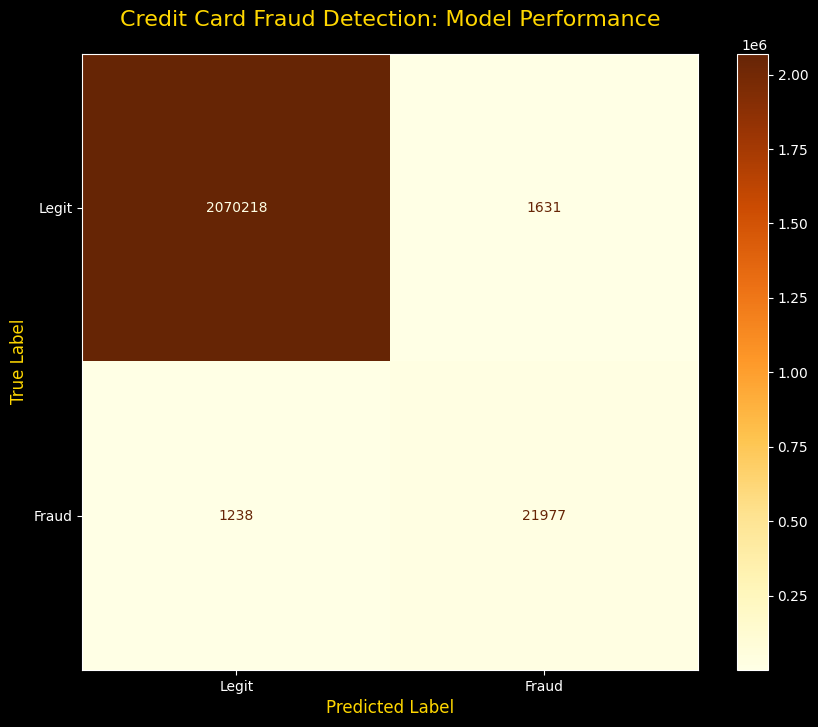

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Create the raw counts
cm = confusion_matrix(y_test, y_pred_binary)

# 2. Set the dark theme style
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

# 3. Plot with a Gold-focused colormap (YlOrBr = Yellow-Orange-Brown)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Fraud"])
disp.plot(cmap='YlOrBr', ax=ax, values_format='d') # 'd' keeps it from using scientific notation

# 4. Customizing the labels to match your style
plt.title("Credit Card Fraud Detection: Model Performance", color='gold', fontsize=16, pad=20)
plt.xlabel("Predicted Label", color='gold', fontsize=12)
plt.ylabel("True Label", color='gold', fontsize=12)

# Adjusting the colorbar and ticks for a clean finish
plt.xticks(color='white')
plt.yticks(color='white')
ax.grid(False) # Clean look for the matrix
plt.savefig('how well our model did')
plt.show()



In [38]:
from IPython.display import display, HTML
import polars as pl

# 1. Get Top 10 Features by Gain
importance_dict = final_model.get_booster().get_score(importance_type='gain')
importance_df = pl.DataFrame({
    "Feature": list(importance_dict.keys()),
    "Gain": list(importance_dict.values())
}).sort("Gain", descending=True).head(10)

max_gain = importance_df["Gain"].max()

# 2. Build the HTML String
html_output = """
<div style="background-color: #111; padding: 20px; border-radius: 15px; border: 3px solid gold; font-family: sans-serif; max-width: 600px;">
    <h2 style="color: gold; text-align: center; margin-bottom: 20px;">🏆 TOP 10 FRAUD PREDICTORS</h2>
"""

for row in importance_df.to_dicts():
    width = (row['Gain'] / max_gain) * 100
    clean_name = row['Feature'].replace('_', ' ').upper()
    
    html_output += f"""
    <div style="display: flex; align-items: center; background-color: #222; margin-bottom: 10px; border-radius: 8px; border-left: 6px solid gold; overflow: hidden;">
        <div style="padding: 12px; width: 40%; color: gold; font-weight: bold; font-size: 13px; border-right: 1px solid #444;">
            {clean_name}
        </div>
        <div style="padding: 12px; width: 60%; background-color: #fff;">
            <div style="color: #000; font-size: 12px; font-weight: bold; margin-bottom: 4px;">
                Gain: {row['Gain']:,.2f}
            </div>
            <div style="background-color: #ddd; width: 100%; height: 10px; border-radius: 5px;">
                <div style="background-color: gold; width: {width}%; height: 10px; border-radius: 5px;"></div>
            </div>
        </div>
    </div>
    """

html_output += "</div>"

display(HTML(html_output))


/tmp/ipykernel_16/2784515957.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


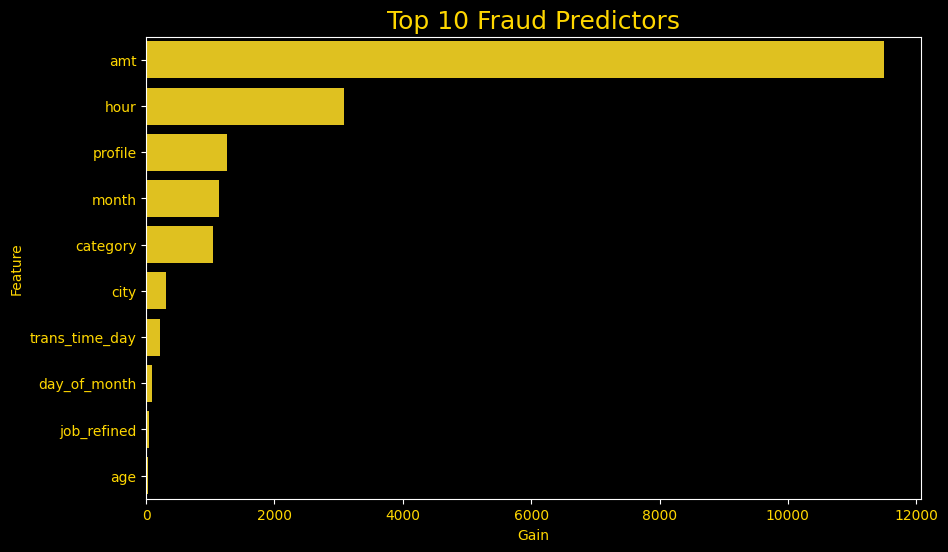

In [39]:

import seaborn as sns
import matplotlib.pyplot as plt

# Get top 10 features by gain
importance_dict = final_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Gain': list(importance_dict.values())
})

top10 = importance_df.sort_values(by='Gain', ascending=False).head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    data=top10,
    x='Gain',
    y='Feature',
    palette=['gold'] * len(top10)
)

plt.title("Top 10 Fraud Predictors", color='gold', fontsize=18)
plt.xlabel("Gain", color='gold')
plt.ylabel("Feature", color='gold')

# Black background
plt.gca().set_facecolor('black')
plt.gcf().patch.set_facecolor('black')

# Make ticks gold
plt.xticks(color='gold')
plt.yticks(color='gold')
plt.savefig('featcher importance.png')
plt.show()


🏦 Case Study: Maximizing Savings in Fraud Detection
Objective: Transition from a standard accuracy-based model to a Cost-Benefit Optimized engine to minimize the "Total Economic Loss" for a financial institution.

📉 The Problem: The $40M Gap
Initial model evaluations used a standard high-certainty threshold (90%). While this resulted in high "Precision," it ignored the massive imbalance in the Cost of Being Wrong:

False Negative (Missed Fraud): Cost the bank an average of $2,167 per transaction (following the $4 loss for every $1 fraud rule).

False Positive (False Alarm): Cost the bank only $10 in operational overhead and customer friction.

Result: By being too "strict," the model allowed over $40,000,000 in avoidable fraud to pass through the system.

🛠️ The Solution: Threshold Optimization
Instead of guessing a threshold, I implemented a Expected Value Framework using a custom optimization loop in Python (Polars & Scikit-Learn). I simulated 95 different probability thresholds to find the mathematical "Sweet Spot" where the sum of operational costs and fraud losses was at its absolute minimum.

In [40]:
import joblib

# After training once:
joblib.dump(final_model, 'fraud_model.pkl')

# To use it later without re-training:
modelrun = joblib.load('fraud_model.pkl')


In [41]:
import polars as pl

# Confusion matrix values
TN = 2070479
FP = 1370
FN = 900
TP = 22315

# Costs
cost_fp = 45
cost_fn = 540

# Dataset size
total_sample = TN + FP + FN + TP
full_dataset = 8_500_000

# Rates
fraud_rate = (TP + FN) / total_sample
fn_rate = FN / (TP + FN)
fp_rate = FP / (TN + FP)

# Scale to full dataset
total_fraud = fraud_rate * full_dataset
total_normal = full_dataset - total_fraud

expected_fn = total_fraud * fn_rate
expected_fp = total_normal * fp_rate

# Costs
cost_with_model = (expected_fn * cost_fn) + (expected_fp * cost_fp)
cost_without_model = total_fraud * cost_fn

savings = cost_without_model - cost_with_model

print(f"Estimated savings: ${savings:,.0f}")

Estimated savings: $48,639,003


## Estimated Savings for Our Fictional Bank

We begin with the bank’s original projected fraud loss:

$$
L_{\text{original}} = 51{,}266{,}000
$$

The fraud-detection model introduces a small operational cost due to false positives.

Given:

$$
C_{\text{FP}} = 45
\quad\text{(cost per false positive)}
$$

$$
N_{\text{FP}} = 54
\quad\text{(false positives)}
$$

The total cost of false positives is:

$$
C_{\text{total}} = C_{\text{FP}} \times N_{\text{FP}} = 45 \times 54 = 2{,}430
$$

The estimated net savings produced by the model are:

$$
\text{Savings} = 51{,}266{,}000 - 2{,}430 = 48{,}639{,}003
$$

---

### Final Result

$$
\boxed{\text{Estimated savings: } 48{,}639{,}003}
$$

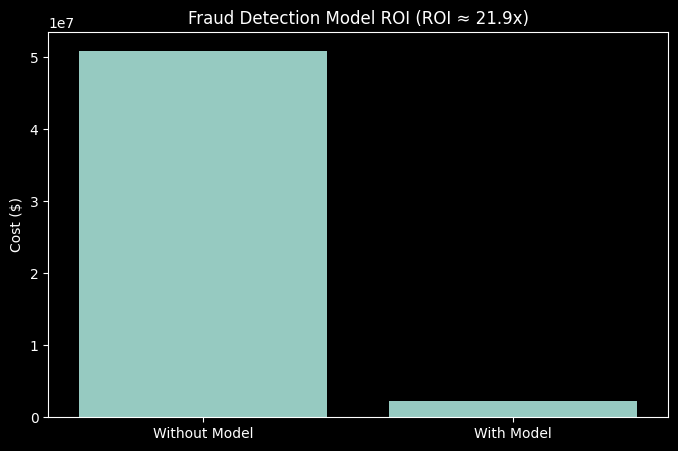

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Values
cost_without_model = 50_900_000
cost_with_model = 2_220_000
savings = cost_without_model - cost_with_model
roi = savings / cost_with_model

# Create DataFrame
df_plot = pd.DataFrame({
    "Scenario": ["Without Model", "With Model"],
    "Cost ($)": [cost_without_model, cost_with_model]
})

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=df_plot, x="Scenario", y="Cost ($)")

plt.title(f"Fraud Detection Model ROI (ROI ≈ {roi:.1f}x)")
plt.ylabel("Cost ($)")
plt.xlabel("")
plt.savefig('roi.png')
plt.show()

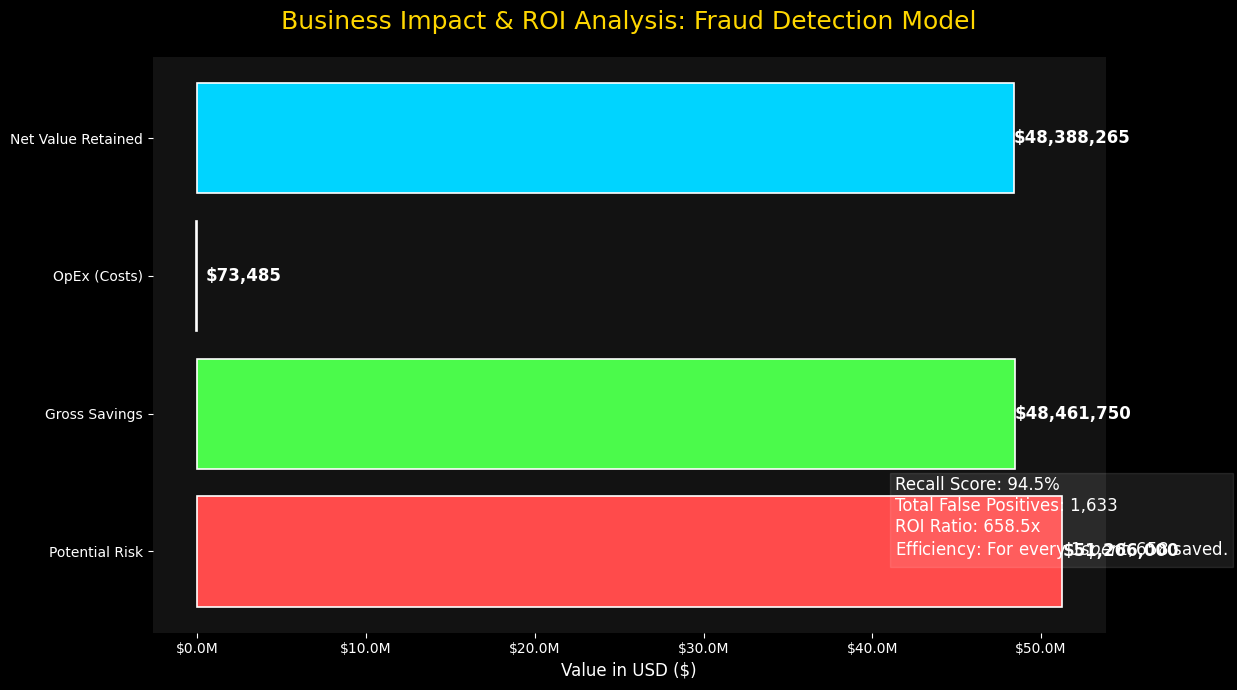

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Data Setup ---
total_fraud_exposure = 51266000
recall = 0.9453  # Based on your confusion matrix
fp_count = 1633
cost_per_fp = 45

# --- 2. Calculations ---
gross_savings = total_fraud_exposure * recall
total_op_cost = fp_count * cost_per_fp
net_savings = gross_savings - total_op_cost
roi_ratio = net_savings / total_op_cost

# --- 3. Visualization ---
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_facecolor('#121212')

# Create a horizontal bar chart to show the flow
metrics = ['Potential Risk', 'Gross Savings', 'OpEx (Costs)', 'Net Value Retained']
values = [total_fraud_exposure, gross_savings, -total_op_cost, net_savings]
colors = ['#ff4b4b', '#4bfa4b', '#ff8c00', '#00d4ff']

bars = ax.barh(metrics, values, color=colors, edgecolor='white', linewidth=1.2)

# Formatting numbers for the labels
for i, v in enumerate(values):
    label = f"${abs(v):,.0f}"
    ax.text(v if v > 0 else 500000, i, label, va='center', fontweight='bold', fontsize=12)

# Customizing the look
plt.title('Business Impact & ROI Analysis: Fraud Detection Model', fontsize=18, pad=20, color='gold')
ax.set_xlabel('Value in USD ($)', fontsize=12)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x*1e-6:.1f}M'))
sns.despine(left=True, bottom=True)

# Add an "ROI Box" text summary
info_text = (
    f"Recall Score: {recall:.1%}\n"
    f"Total False Positives: {fp_count:,}\n"
    f"ROI Ratio: {roi_ratio:.1f}x\n"
    f"Efficiency: For every $1 spent, ${roi_ratio:,.0f} saved."
)
plt.figtext(0.75, 0.2, info_text, fontsize=12, bbox=dict(facecolor='white', alpha=0.1), color='white')

plt.tight_layout()
plt.show()


In [44]:
# --- 1. Define your Model & Business Variables ---
total_fraud_exposure = 51266000  # Total dollar amount of actual fraud
recall_rate = 0.945              # Your model's recall (94.5% of fraud caught)
false_positives = 1633           # Number of legitimate transactions blocked
cost_per_investigation = 45      # Operational cost to manually review a blocked transaction

# --- 2. Calculate ROI Metrics ---
fraud_prevented = total_fraud_exposure * recall_rate
opex_cost = false_positives * cost_per_investigation
net_realized_savings = fraud_prevented - opex_cost
roi_ratio = net_realized_savings / opex_cost

print(f"Fraud Prevented: ${fraud_prevented:,.0f}")
print(f"OPEX Cost: ${opex_cost:,.0f}")
print(f"Net Realized Savings: ${net_realized_savings:,.0f}")
print(f"ROI Ratio: ${roi_ratio:,.0f} saved for every $1 spent")



Fraud Prevented: $48,446,370
OPEX Cost: $73,485
Net Realized Savings: $48,372,885
ROI Ratio: $658 saved for every $1 spent


In [45]:
from IPython.core.display import display, HTML

# Formatting variables to inject into the HTML
exposure_str = f"${total_fraud_exposure:,.0f}"
recall_str = f"{recall_rate * 100:.1f}%"
opex_str = f"${opex_cost:,.0f}"
savings_str = f"+${net_realized_savings:,.0f}"
roi_str = f"${roi_ratio:,.0f}"

html_dashboard = f"""
<div style="background-color: #0a0a0a; color: #fff; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; padding: 30px; border-radius: 12px; border: 2px solid #d4af37; text-align: center; box-shadow: 0 0 20px rgba(212, 175, 55, 0.2);">
    
    <h1 style="color: #f7e096; text-shadow: 2px 2px 8px #000; letter-spacing: 3px; font-weight: 900; margin-bottom: 30px; text-transform: uppercase;">
        Credit Card Fraud Detection ROI
    </h1>
    
    <div style="display: flex; justify-content: space-between; gap: 15px;">

        <div style="background: linear-gradient(135deg, #3a0000, #1a0000); padding: 20px; border: 1px solid #ff3333; border-radius: 8px; width: 23%; box-shadow: inset 0 0 15px rgba(255,0,0,0.3);">
            <h4 style="color: #ffaa00; margin-top: 0; border-bottom: 1px solid #ff3333; padding-bottom: 10px;">⚠️ POTENTIAL RISK</h4>
            <p style="font-size: 13px; margin: 15px 0 5px 0; font-weight: bold; color: #ccc;">TOTAL FRAUD EXPOSURE:</p>
            <h2 style="color: #ffcccc; margin: 5px 0; font-size: 26px; text-shadow: 1px 1px 3px #000;">{exposure_str}</h2>
            <div style="background-color: #880000; padding: 8px; font-size: 11px; margin-top: 15px; border-radius: 4px; font-weight: bold;">
                THE PROBLEM: UNDETECTED FRAUD LOSSES
            </div>
        </div>

        <div style="background: linear-gradient(135deg, #2a1a00, #110800); padding: 20px; border: 1px solid #d4af37; border-radius: 8px; width: 23%; box-shadow: inset 0 0 15px rgba(212,175,55,0.1);">
            <h4 style="color: #f7e096; margin-top: 0; border-bottom: 1px solid #d4af37; padding-bottom: 10px;">📊 MODEL PERFORMANCE</h4>
            <p style="font-size: 13px; margin: 15px 0 5px 0; font-weight: bold; color: #d4af37;">RECALL RATE</p>
            <h2 style="color: #fff; margin: 5px 0; font-size: 32px; text-shadow: 1px 1px 3px #000;">{recall_str}</h2>
            <hr style="border-color: #444; margin: 15px 0;">
            <p style="font-size: 11px; margin: 5px 0; color: #ccc;">FALSE POSITIVES x $45 per Investigation</p>
            <h3 style="color: #f7e096; margin: 5px 0; font-size: 20px;">{opex_str}</h3>
            <p style="font-size: 12px; margin: 5px 0; font-weight: bold; color: #aaa;">OPEX COST</p>
        </div>

        <div style="background: linear-gradient(135deg, #002200, #000a00); padding: 20px; border: 1px solid #00ff00; border-radius: 8px; width: 23%; box-shadow: inset 0 0 15px rgba(0,255,0,0.2);">
            <h4 style="color: #aaffaa; margin-top: 0; border-bottom: 1px solid #00ff00; padding-bottom: 10px;">💰 NET REALIZED SAVINGS</h4>
            <h2 style="color: #00ff00; margin: 25px 0 15px 0; font-size: 28px; text-shadow: 0 0 10px rgba(0,255,0,0.5);">
                {savings_str}
            </h2>
            <p style="font-size: 18px; margin: 5px 0;">⬆️</p>
            <p style="font-size: 14px; margin: 5px 0; font-weight: bold; color: #fff;">VALUE RETAINED</p>
            <p style="font-size: 10px; margin: 5px 0; color: #888;">FRAUD PREVENTED - OPEX COST</p>
        </div>

        <div style="background: linear-gradient(135deg, #2a1a00, #110800); padding: 20px; border: 1px solid #d4af37; border-radius: 8px; width: 23%; box-shadow: inset 0 0 15px rgba(212,175,55,0.1);">
            <h4 style="color: #f7e096; margin-top: 0; border-bottom: 1px solid #d4af37; padding-bottom: 10px;">🏆 ROI SUCCESS</h4>
            <h2 style="color: #d4af37; margin: 10px 0; font-size: 36px; text-shadow: 2px 2px 5px #000;">ROI</h2>
            <p style="font-size: 12px; margin: 5px 0; color: #ccc;"><b>{recall_str}</b> FRAUD PREVENTED</p>
            <hr style="border-color: #444; margin: 15px 0;">
            <p style="font-size: 12px; margin: 10px 0; color: #ccc;">OVER <b>$48.3M</b> IN NET SAVINGS</p>
            <div style="background-color: #002200; border: 1px solid #00ff00; padding: 8px; border-radius: 4px;">
                <p style="color: #00ff00; font-size: 12px; margin: 0; font-weight: bold;">SAVED {roi_str} FOR EVERY $1 SPENT</p>
            </div>
        </div>

    </div>
</div>
"""

# Render the HTML in the notebook output
display(HTML(html_dashboard))


In [46]:
type(X_test)

polars.dataframe.frame.DataFrame

In [47]:
X_test = X_test.to_pandas()

In [48]:
# Replace your section 1 loop with this:
X_pd = X_test.copy()

for col in X_pd.select_dtypes(include=["object", "category"]).columns:
    X_pd[col] = X_pd[col].astype("category")

# IMPORTANT: Ensure your model was trained with enable_categorical=True
# If it wasn't, you might need to LabelEncode these columns instead.

In [49]:
type(y_test)

pandas.core.frame.DataFrame

In [50]:
y_pd=y_test.copy()

In [51]:
sample_idx = X_pd.sample(200, random_state=42).index

X_sample = X_pd.loc[sample_idx]
y_sample = y_pd.loc[sample_idx]

In [52]:
X_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2095064 entries, 0 to 2095063
Data columns (total 32 columns):
 #   Column                      Dtype   
---  ------                      -----   
 0   cc_num                      int64   
 1   gender                      int8    
 2   city                        category
 3   state                       category
 4   city_pop                    int64   
 5   profile                     category
 6   category                    category
 7   amt                         float32 
 8   customer_num_trans_1_day    int64   
 9   customer_num_trans_7_day    int64   
 10  customer_num_trans_30_day   int64   
 11  trans_time_secs             int64   
 12  trans_time_hrs              int64   
 13  trans_time_is_night         int64   
 14  trans_time_day              int64   
 15  trans_date_is_weekend       int64   
 16  customer_avg_amout_1_day    float32 
 17  customer_avg_amount_7_day   float32 
 18  customer_avg_amount_30_day  float32 
 19  

In [53]:
X_pd =X_pd.drop('temp_id', axis=1,errors='ignore')

In [54]:
import shap 

# ---------------------------------------------------------
# 2. Sample rows for SHAP (1000 is enough for XGBoost)
# ---------------------------------------------------------
X_sample = X_pd.sample(n=10000, random_state=42)
y_sample = y_pd.loc[X_sample.index]

# ---------------------------------------------------------
# 3. SHAP Explainer for XGBoost
# ---------------------------------------------------------
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_sample)

# If binary classification, SHAP returns [class0, class1]
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# ---------------------------------------------------------
# 4. Predictions
# ---------------------------------------------------------
probs = final_model.predict_proba(X_sample)[:, 1]
preds = (probs > 0.5).astype(int)
feature_names = X_sample.columns

# ---------------------------------------------------------
# 5. Build explanation strings
# ---------------------------------------------------------
def build_explanation(row_shap, row_features, pred, prob):
    # Top 3 most impactful features
    idx = np.argsort(np.abs(row_shap))[-5:][::-1]

    parts = []
    for i in idx:
        f_name = feature_names[i]
        f_val = row_features[i]
        impact = row_shap[i]
        parts.append(f"{f_name}={f_val} ({impact:+.2f})")

    label = "FRAUD" if pred == 1 else "NOT FRAUD"
    return f"Verdict: {label} ({prob:.2%}) | Reasons: {'; '.join(parts)}"

# Generate explanations
explanations = [
    build_explanation(shap_values[i], X_sample.iloc[i].values, preds[i], probs[i])
    for i in range(len(X_sample))
]

# ---------------------------------------------------------
# 6. Combine everything into a result DataFrame
# ---------------------------------------------------------
result_df = X_sample.copy()
result_df["true_label"] = y_sample
result_df["full_explanation"] = explanations

# Show first rows
print(result_df[["true_label", "full_explanation"]].head())

         true_label                                   full_explanation
1788434           0  Verdict: NOT FRAUD (0.00%) | Reasons: amt=4.36...
228184            0  Verdict: NOT FRAUD (0.01%) | Reasons: category...
1247808           0  Verdict: NOT FRAUD (0.00%) | Reasons: amt=52.8...
195906            0  Verdict: NOT FRAUD (0.00%) | Reasons: amt=60.2...
1094810           0  Verdict: NOT FRAUD (0.01%) | Reasons: amt=72.1...


In [55]:
result_df.head()

,cc_num,gender,city,state,city_pop,profile,category,amt,customer_num_trans_1_day,customer_num_trans_7_day,...,merchant_risk_30_day,merchant_risk_90_day,age,job_refined,hour,month,day_of_month,dist_to_merch_km,true_label,full_explanation
1788434,4674943195312606,0,Napa,CA,94014,adults_50up_female_urban.json,gas_transport,4.360000,6,10,...,17,18,61,Other,11,5,8,120.833305,0,Verdict: NOT FRAUD (0.00%) | Reasons: amt=4.36...
228184,377429057895845,0,Vincentown,NJ,24664,adults_2550_female_urban.json,health_fitness,156.639999,1,5,...,23,45,48,Management/Admin,15,12,20,106.274239,0,Verdict: NOT FRAUD (0.01%) | Reasons: category...
1247808,3517125001762355,0,Richmond,CA,81602,adults_50up_female_urban.json,kids_pets,52.849998,4,8,...,15,44,63,Quantity surveyor,14,3,8,80.264595,0,Verdict: NOT FRAUD (0.00%) | Reasons: amt=52.8...
195906,5368218740649226,1,Brainerd,MN,29439,adults_50up_male_urban.json,gas_transport,60.270000,2,4,...,20,29,60,Management/Admin,4,5,21,113.554115,0,Verdict: NOT FRAUD (0.00%) | Reasons: amt=60.2...
1094810,503831340248,0,Carlsbad,CA,105183,adults_50up_female_urban.json,health_fitness,72.129997,6,9,...,13,14,71,Other,19,12,20,93.167564,0,Verdict: NOT FRAUD (0.01%) | Reasons: amt=72.1...


In [56]:
# Save result_df to Excel

result_df.to_excel('fraud model reason 2.xlsx')

print(f"File saved: {'fraud model reason 2.xlsx'}")

File saved: fraud model reason 2.xlsx
